# Tratamiento de Valores Faltantes por Imputación a la Media/Mediana

En este notebook aprenderemos cómo manejar los valores faltantes (*missing values*) en un dataset utilizando técnicas de imputación estadística simple: la **media** y la **mediana**.

## 1. Teoría: Tipos de Valores Faltantes

Antes de imputar, es importante entender por qué faltan los datos:
- **MCAR (Missing Completely at Random):** El hecho de que falte un dato no tiene relación con ninguna otra variable ni con el valor mismo.
- **MAR (Missing at Random):** La probabilidad de que falte un dato depende de otras variables observadas.
- **MNAR (Missing Not at Random):** La falta de datos depende del valor que falta (ej. personas con altos ingresos no suelen declararlos).

## 2. Imputación por Media vs Mediana

- **Media (Promedio):** Se utiliza cuando los datos siguen una distribución normal (simétrica) y no hay valores atípicos (*outliers*) significativos.
- **Mediana (Valor Central):** Es más robusta. Se prefiere cuando los datos están sesgados o contienen *outliers*, ya que la media se ve muy afectada por valores extremos.

## 3. Implementación en Python

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer

### Carga de Datos
Usaremos el dataset `train_loan.csv` que contiene información sobre préstamos.

In [2]:
df = pd.read_csv('train_loan.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


### Identificación de Valores Faltantes

In [3]:
print("Valores faltantes por columna:")
print(df.isnull().sum())

Valores faltantes por columna:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


### Imputación de la variable `LoanAmount` (Monto del Préstamo)

Primero veamos la distribución para decidir si usar media o mediana.

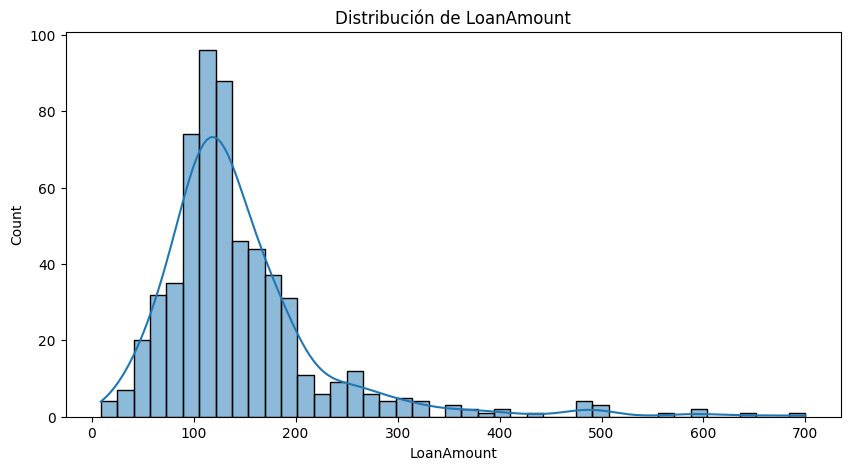

Media: 146.41216216216216
Mediana: 128.0


In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(df['LoanAmount'], kde=True)
plt.title('Distribución de LoanAmount')
plt.show()

print(f"Media: {df['LoanAmount'].mean()}")
print(f"Mediana: {df['LoanAmount'].median()}")

Como la distribución tiene cierto sesgo a la derecha, la **mediana** suele ser una mejor opción, aunque la media también es común. Vamos a aplicar ambas para comparar.

#### Opción A: Usando Pandas

In [5]:
df_pandas = df.copy()
# Imputación por media
df_pandas['LoanAmount_Mean'] = df_pandas['LoanAmount'].fillna(df_pandas['LoanAmount'].mean())

# Imputación por mediana
df_pandas['LoanAmount_Median'] = df_pandas['LoanAmount'].fillna(df_pandas['LoanAmount'].median())

print(df_pandas[['LoanAmount', 'LoanAmount_Mean', 'LoanAmount_Median']].isnull().sum())

LoanAmount           22
LoanAmount_Mean       0
LoanAmount_Median     0
dtype: int64


#### Opción B: Usando Scikit-Learn (Recomendado para Pipelines)

In [6]:
imputer_mean = SimpleImputer(strategy='mean')
imputer_median = SimpleImputer(strategy='median')

# Ajustar y transformar (requiere reshapping a 2D)
df['LoanAmount_Imputed'] = imputer_median.fit_transform(df[['LoanAmount']])

print(f"Valores nulos después de imputar: {df['LoanAmount_Imputed'].isnull().sum()}")

Valores nulos después de imputar: 0


## Conclusión

La imputación por media/mediana es rápida y efectiva para variables numéricas. Sin embargo, reduce la varianza del dataset y no tiene en cuenta las relaciones entre variables. En casos más complejos, se podrían usar técnicas como KNN Imputer o Iterative Imputer.